## DANGSUGAR STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

dangsugar=pd.read_csv('../stock_data/dangsugar.csv') ## so it can be small letter. This is cool.
dangsugar=dangsugar.drop(columns=['high_price','low_price'])
dangsugar.rename(columns={'trade_date':'date'},inplace=True)
dangsugar['date']=pd.to_datetime(dangsugar['date'])
dangsugar['month']=dangsugar['date'].dt.month
dangsugar['quarter']=dangsugar['date'].dt.quarter
dangsugar['year']=dangsugar['date'].dt.year

dangsugar

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42793,DANGSUGAR,2017-01-03,6.11,6.11,213145,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43353,DANGSUGAR,2017-01-04,5.99,5.99,749928,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43463,DANGSUGAR,2017-01-05,5.99,5.99,146823,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43573,DANGSUGAR,2017-01-06,5.99,5.99,72303,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43663,DANGSUGAR,2017-01-09,6.14,6.14,375889,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298051,DANGSUGAR,2026-07-13,72.00,72.00,3204953,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298489,DANGSUGAR,2026-07-14,72.00,72.00,6606234,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298927,DANGSUGAR,2026-07-15,72.00,72.00,2168102,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299365,DANGSUGAR,2026-07-16,72.95,72.95,3083596,2026-07-16T15:10:03.113936+00:00,7,3,2026


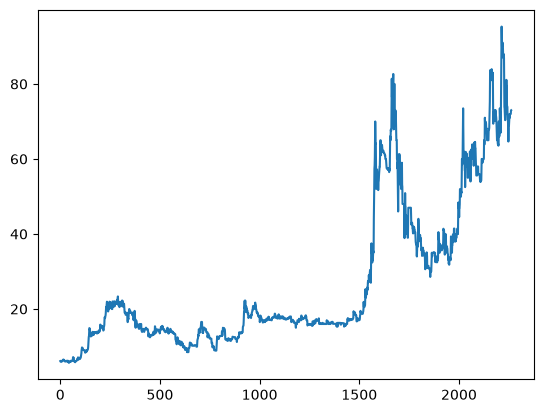

In [2]:
import matplotlib.pyplot as plt

plt.plot(dangsugar['close_price'])
plt.show()

In [3]:
dangsugar_end_month_df = (
    dangsugar
    .sort_values("date")
    .groupby(dangsugar["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

dangsugar_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45363,DANGSUGAR,2017-01-31,6.32,6.32,627181,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47184,DANGSUGAR,2017-02-28,6.02,6.02,69494,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49300,DANGSUGAR,2017-03-31,6.52,6.52,1940752,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51128,DANGSUGAR,2017-04-28,6.20,6.20,296007,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53050,DANGSUGAR,2017-05-31,7.03,7.03,14426283,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35287,DANGSUGAR,2026-03-31,66.05,66.05,6360558,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281114,DANGSUGAR,2026-04-30,69.70,69.70,2998185,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284180,DANGSUGAR,2026-05-29,73.90,73.90,18695555,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294109,DANGSUGAR,2026-06-30,67.80,67.80,5063598,2026-06-30T15:10:03.08168+00:00,6,2,2026


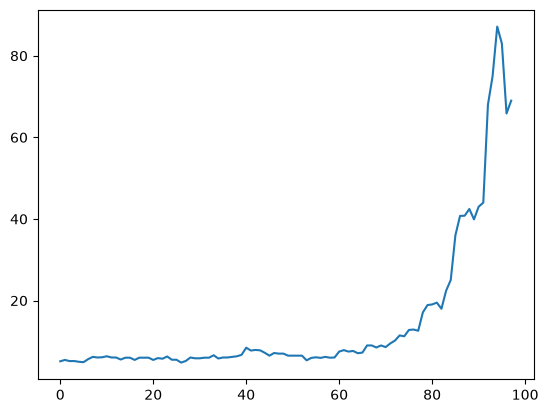

In [ ]:
plt.plot(dangsugar_end_month_df['close_price'])
plt.show()

In [4]:
dangsugar_end_month_df['returns']=dangsugar_end_month_df['close_price'].pct_change()*100
dangsugar_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45363,DANGSUGAR,2017-01-31,6.32,6.32,627181,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47184,DANGSUGAR,2017-02-28,6.02,6.02,69494,2026-04-08T02:44:45.006295+00:00,2,1,2017,-4.746835
2,49300,DANGSUGAR,2017-03-31,6.52,6.52,1940752,2026-04-08T02:45:42.281198+00:00,3,1,2017,8.305648
3,51128,DANGSUGAR,2017-04-28,6.20,6.20,296007,2026-04-08T02:51:55.619599+00:00,4,2,2017,-4.907975
4,53050,DANGSUGAR,2017-05-31,7.03,7.03,14426283,2026-04-08T02:52:57.421655+00:00,5,2,2017,13.387097
...,...,...,...,...,...,...,...,...,...,...,...
110,35287,DANGSUGAR,2026-03-31,66.05,66.05,6360558,2026-03-31T15:00:02.085058+00:00,3,1,2026,-20.373719
111,281114,DANGSUGAR,2026-04-30,69.70,69.70,2998185,2026-04-30T15:00:02.170664+00:00,4,2,2026,5.526117
112,284180,DANGSUGAR,2026-05-29,73.90,73.90,18695555,2026-05-29T15:00:02.455558+00:00,5,2,2026,6.025825
113,294109,DANGSUGAR,2026-06-30,67.80,67.80,5063598,2026-06-30T15:10:03.08168+00:00,6,2,2026,-8.254398


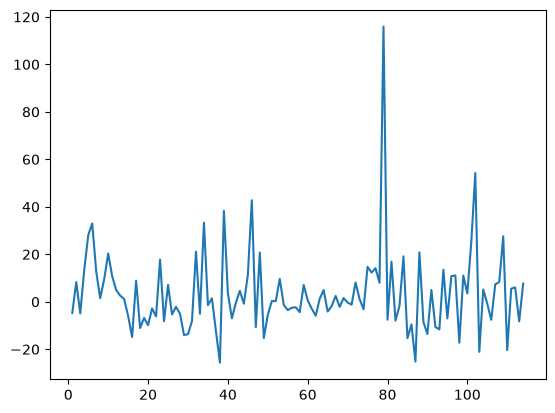

In [5]:
plt.plot(dangsugar_end_month_df['returns'])
plt.show()

In [6]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(dangsugar_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-11.120419305953595), np.float64(3.477200799649473e-20), 0, 113, {'1%': np.float64(-3.489589552580676), '5%': np.float64(-2.887477210140433), '10%': np.float64(-2.580604145195395)}, np.float64(861.5170114199415))
stationary


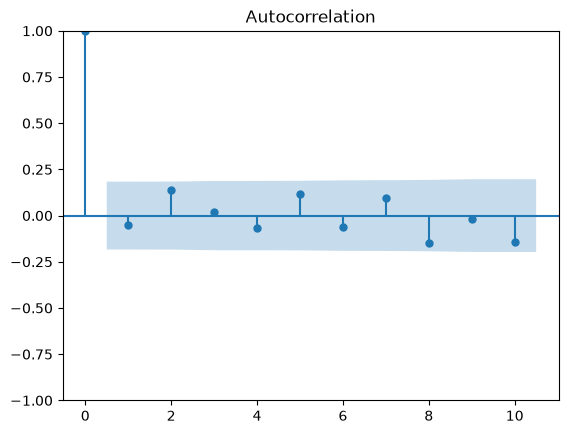

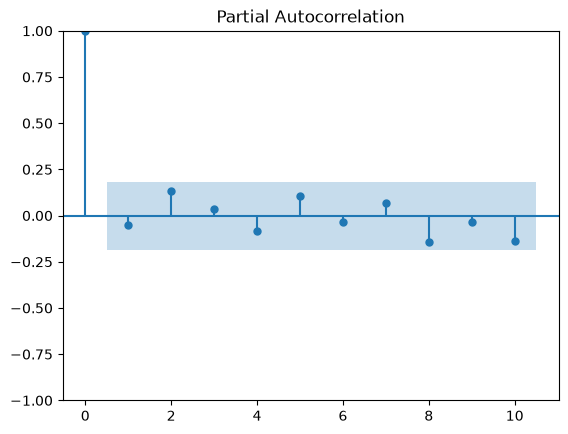

In [7]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(dangsugar_end_month_df['returns'].dropna(), lags=10)
plot_pacf(dangsugar_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [8]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=dangsugar_end_month_df['close_price'][:-10]
test=dangsugar_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -80.87997001781521]
[0, 0, 0, 0, 0, 1, -65.7230534581244]
[0, 0, 0, 0, 0, 2, -32.66545988778604]
[0, 0, 0, 0, 1, 0, -14.321189482789547]
[0, 0, 0, 0, 1, 1, -13.251810033155833]
[0, 0, 0, 0, 1, 2, -2.2359132732539777]
[0, 0, 0, 0, 2, 0, -40.492408539252835]
[0, 0, 0, 0, 2, 1, -11.336985493795563]
[0, 0, 0, 0, 2, 2, -1.8551504914663757]
[0, 0, 0, 1, 0, 0, -20.373740151192273]
[0, 0, 0, 1, 0, 1, -16.559642918799366]
[0, 0, 0, 1, 0, 2, -4.075264015335814]
[0, 0, 0, 1, 1, 0, -8.752642326820922]
[0, 0, 0, 1, 1, 1, -8.12697851772594]
[0, 0, 0, 1, 1, 2, -2.115418026286506]
[0, 0, 0, 1, 2, 0, -1.1824912859287129]
[0, 0, 0, 1, 2, 1, -2.1608744270512896]
[0, 0, 0, 1, 2, 2, -0.9888472155710588]
[0, 0, 0, 2, 0, 0, -11.99817754242333]
[0, 0, 0, 2, 0, 1, -11.398752668504967]
[0, 0, 0, 2, 0, 2, -3.91173731298424]
[0, 0, 0, 2, 1, 0, -7.316924036778744]
[0, 0, 0, 2, 1, 1, -9.270963971448136]
[0, 0, 0, 2, 1, 2, -3.6866030237714167]
[0, 0, 0, 2, 2, 0, -0.9459830539305949]
[0, 0, 0, 2, 2

In [9]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
222,0,2,2,0,2,0,-286.987383
706,2,2,2,0,2,0,-235.159107
438,1,2,1,0,2,0,-225.342071
465,1,2,2,0,2,0,-207.633408
652,2,2,0,0,2,0,-181.737210
...,...,...,...,...,...,...,...
212,0,2,1,2,1,2,0.275686
203,0,2,1,1,1,2,0.294737
211,0,2,1,2,1,1,0.301197
705,2,2,2,0,1,2,0.303013


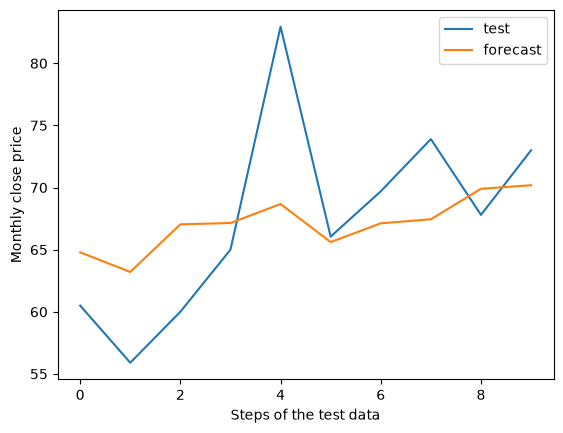

r2_score:  0.3063049329086033
rmse:  6.2494081037128915
description:  count    115.000000
mean      27.071826
std       19.560778
min        6.020000
25%       13.850000
50%       17.400000
75%       36.950000
max       82.950000
Name: close_price, dtype: float64


In [10]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=dangsugar_end_month_df['close_price'][:-10]
y_test=dangsugar_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,2,2), 
seasonal_order=(1,1,1,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', dangsugar_end_month_df.close_price.describe())

Its not capturing the variations properly. But we will work with this.